Agent that will help Register Customers for an Event. Key Task of Agent.
1. Request Input from User.
2. Register User for the Event.
3. Notify after Successful Register.
4. Use RAG (FAQ) to get details to be asked.

Agent Functions / Tools
1. Register Customer Function / Tool.
2. Send EMail Function / Tool
3. Connect to RAG to retrieve Function / Tool

Agent Instructions (System Instructions)
1. Request Input from User.
2. Register the User based on Input.
3. If the Registration is a Failure, First Get the Schedule and include that in the User Registration Status Notification.
4. If the Registration is Successful, Send the User Registration Status Notification.
5. Check for Fees. Send EMail Notification on Fee Check.
*** Above instructions are set as part of System Prompt / Execution Plan.

Adding Intent Management
1. When a Conversation is provided, Agent will check if the conversation triggers a planned Intent. 
2. If the Planned Intented is selected, that Plan gets executed interactively.

Key Observation
1. It has been observed that - if Agent has been provided with Tools, for any step in Plan there are 
No Tools, it can execute a Tool with close enough meaning.
2. Example: If i have Get_UserInfo Step as the start of the Plan, when i input the values as a respone from FAQ
Validate & Register Step seems to be called automatically though no Context or a Plan hs been given. Only commonality was that the augments for the Tool Function (Validate & Register) are both UserInfo Object
3. In order to prevent that we created a dummy Tool Function (Get_UserInfo) so that it gets called as part of the Input Flow and no other. This will prevent random Tool calls by the LLM.


In [44]:
# Import Python Native Lib
import os
import keyboard
import configparser
import numpy as np
import uuid as uuid
from dotenv import load_dotenv

from typing_extensions import Annotated, TypedDict, Literal
from IPython.display import Image, display

# Import Pandas
import pandas as pd

# Import LangGraph & LangChain packages
from langgraph.types import Command
from langgraph.graph import StateGraph, START, END, MessageGraph
from langgraph.graph.message import MessageGraph, add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain.tools import tool
from langgraph.prebuilt import InjectedState
#from langchain_core.tools.base import InjectedToolCallId
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage, AnyMessage, RemoveMessage

# Import OpenAI Chat package
from langchain_openai import ChatOpenAI

# Import Sentence Ebedding Transformer
import textwrap as tw
from sentence_transformers import SentenceTransformer

# Import RAG DB FAISS
import faiss

# Load Env Variables
load_dotenv()


True

In [45]:
# Arguments & DataModels

# Tool Function Arguments
class UserInfo(TypedDict):
    first_name: str
    last_name: str
    user_age: int
    user_email: str
    user_phone: int

class NotifyInfo(TypedDict):
    notify_msg: str
    user_email: str

class EventSchedule(TypedDict):
    schedule: str

class EventFees(TypedDict):
    fee_detail: str


# Langgraph ProcessFlow Arguments
class State(TypedDict):
    user_info: UserInfo
    notify_info: NotifyInfo
    event_schedule: EventSchedule
    messages: Annotated[list[AnyMessage], add_messages]

# "out_message" should be named different so as to avoid clash with
# Internal State "messages" field from the State Object
# We can also assign 'out_messages' variable to State Object instead of OutputState Object
# and then populate this variable as part of End of Graph Message filtering. 
class OutputState(TypedDict):
    out_messages: list[AnyMessage]

class IntentState(TypedDict):
    int_message: list[AnyMessage] 


In [54]:
#Read the User Registration Plan File
plan_config = configparser.ConfigParser()
file_path = "C:\\RanjithC\\AIProjects\\PromptEngg\\langgraph\\data\\runevent_agent_usr_reg_plan.properties"
with open(file_path, 'r', encoding='utf-8') as file:
    plan_config.read_file(file)
#print("Plan: ", plan_config.options("Context"))

# Create Flow Transition Rules DataFrame
pd_runevent_plan = pd.read_csv("C:\\RanjithC\\AIProjects\\PromptEngg\\langgraph\\data\\runevent_agent_task_plan.csv", sep="|")

def get_transition_context(eventName: str):
    context = list(pd_runevent_plan[pd_runevent_plan['TaskName'] == eventName]["TransitionActivity"])[0]
    if isinstance(context, str):
        context = context.strip()
        if context == "None":
            return("")
        else:
            return(context)
    else:
        return("")

#get_transition_context("Event_Fees")

In [55]:
# Setup a FAISS RAG Datastore and Populate the KB

# Create a DataFrame of Two Columns
pd_data = pd.read_csv("C:\\RanjithC\\AIProjects\\PromptEngg\\langgraph\\data\\runevent_faq.csv", sep="|")
faq_content = pd_data['Questions']

#Create Sentence Embedding 
model = SentenceTransformer('all-MiniLM-L6-v2',similarity_fn_name='cosine', device='cpu')
sentence_embedding = model.encode(faq_content, batch_size=32, output_value="sentence_embedding", convert_to_numpy=True, device="cpu")
print("Embedding Shape: ", sentence_embedding.shape)

# Initialise FAISS Vector Store & Load
fs_vector_index = faiss.IndexFlatL2(sentence_embedding.shape[1])
fs_vector_index.add(sentence_embedding)
print("Vector Count: ", fs_vector_index.ntotal)

# Search FAQ VectorDB
def search_faiss_rag(query: str) -> list[int]:
    query_embedding = model.encode(query, batch_size=32, output_value="sentence_embedding", convert_to_numpy=True, device="cpu")

    query_embedding = query_embedding[np.newaxis, :]  #query_embedding to a 2D Vector of 1 Row and 1 column
    top_dist, top_pos = fs_vector_index.search(query_embedding, k=5)  # Independent Array of Eucl dist and Pos
    
    print("Top Euclidian Dist: ", top_dist)
    print("Top Answers: ", top_pos)

    top_idx = top_pos[0][0]  # Top Result Index Number

    return(pd_data['Answers'][top_idx])


Embedding Shape:  (3, 384)
Vector Count:  3


In [56]:
# Tool / Function.

# Get the ToolCallId from tool_call_Id List
def get_tool_call_Id(tool_call_list: list, func_name: str) -> str:
    
    func_id = ""
    for tool in tool_call_list:
        if tool.get("function").get("name") == func_name:
            func_id = tool.get("id")
            break
    
    return(func_id)


# User Info Save Tool Function.
@tool
def get_userInfo(user_info: UserInfo, state: Annotated[dict, InjectedState]) -> Command:
    """ This tool used to accept User Information for Running Event. 
    Args: user_info: Input Dictionary that will contain User Information for the Assistant.
          state: This is State Object that is passed to Tool Function. 
    Returns: Command: ToolMessage - User Information Update Success or Failure message. """

    # Get State Message and Retrieve AI Tool Message 
    # For getting the Tool-Call-ID
    ai_msg = state["messages"][-1]
    tool_call = ai_msg.additional_kwargs.get("tool_calls")
    tool_call_id = get_tool_call_Id(tool_call, "get_userInfo")              # tool_call[0].get("id")

    print("Get User Info Tool: ", tool_call_id)
    print("Inside Get User Information: ", user_info)

    response = "Profile Update is Success." # \n Assistant Instruction: DO NOT PROCEED TO NEXT STEP. DO NOT ASK USER QUESTIONS."  #User Information Update Successful

    #Get Transition Events
    trans_event = get_transition_context("User_GetProfile")
    response = "ToolResult: " + response + trans_event

    return(Command(update={
        "messages": [ToolMessage(response, tool_call_id=tool_call_id)]}))

# Validate Tool Function.
@tool
def do_validate(user_info: UserInfo, state: Annotated[dict, InjectedState]) -> Command:
    """ This tool used to Validate the User Information for Running Event. 
    Args: user_info: Input Dictionary that will contain information needed for validate the User.
          state: This is State Object that is passed to Tool Function. 
    Returns: Command: ToolMessage - User Validation Succcess or Failure message. """

    # Get State Message and Retrieve AI Tool Message 
    # For getting the Tool-Call-ID
    ai_msg = state["messages"][-1]
    tool_call = ai_msg.additional_kwargs.get("tool_calls")
    tool_call_id = get_tool_call_Id(tool_call, "do_validate")              # tool_call[0].get("id")

    print("User Validation ToolID: ", tool_call_id)
    print("Inside User Validation: ", user_info)

    if user_info.get("user_age") < 40:
        response = "User Age Validation Failed."
    else:
        response = "User Validation is Successful."

    #Get Transition Events
    trans_event = get_transition_context("User_Validate")
    response = "ToolResult: " + response + trans_event

    return(Command(update={
        "messages": [ToolMessage(response, tool_call_id=tool_call_id)]}))


# Register Tool Function.
@tool
def do_register(user_info: UserInfo, state: Annotated[dict, InjectedState]) -> Command:
    """ This tool used to Register a User for Running Event. 
    Args: user_info: Input Dictionary that will contain information needed for register the User.
          state: This is State Object that is passed to Tool Function. 
    Returns: Command: ToolMessage - User Registration Succcess or Failure message. """

    # Get State Message and Retrieve AI Tool Message 
    # For getting the Tool-Call-ID
    ai_msg = state["messages"][-1]
    tool_call = ai_msg.additional_kwargs.get("tool_calls")
    tool_call_id = get_tool_call_Id(tool_call, "do_register")              # tool_call[0].get("id")

    print("User Registration ToolId: ", tool_call_id)
    print("Inside User Registration: ", user_info)

    if (user_info.get("first_name")[-1] != user_info.get("last_name")[-1]):
        response = "User Registration Failed."
    else:
        response = "User Registration Successful."

    #Get Transition Events
    trans_event = get_transition_context("User_Register")
    response = "ToolResult: " + response + trans_event

    return(Command(update={
        "messages": [ToolMessage(response, tool_call_id=tool_call_id)]}))

# Notify User
@tool
def notify_user(notify_info: NotifyInfo, state: Annotated[dict, InjectedState]) -> Command:
    """ This tool used to Notify Users of this Running Event.
    Args: notify_info: Input Dictionary that will contain information to Notify the User.
          state: This is State Object that is passed to Tool Function.
    Returns: Command: ToolMessage - User has been Notifed message. """

    # Get State Message and Retrieve AI Tool Message 
    # For getting the Tool-Call-ID
    ai_msg = state["messages"][-1]
    tool_call = ai_msg.additional_kwargs.get("tool_calls")
    tool_call_id = get_tool_call_Id(tool_call, "notify_user")              # tool_call[0].get("id")

    print("User Notification ToolId: ", tool_call_id)
    print("Inside User Notification: ", notify_info)

    #Get Transition Events
    response = "User Notified."

    trans_event = get_transition_context("User_Notify")
    response = "ToolResult: " + response + trans_event

    return(Command(update={
        "messages": [ToolMessage(response, tool_call_id=tool_call_id)]}))

# Check Cost of Registration
@tool
def get_event_fees(state: Annotated[dict, InjectedState]) -> Command:
    """ Get User Registration fees for the Running Event.
    Args: state: This is State Object that is passed to Tool Function.
    Returns: Command: Update State and Tool Message on the Fees for Running Event."""

    # Get State Message and Retrieve AI Tool Message 
    # For getting the Tool-Call-ID
    ai_msg = state["messages"][-1]
    tool_call = ai_msg.additional_kwargs.get("tool_calls")
    tool_call_id = get_tool_call_Id(tool_call, "get_event_fees")              # tool_call[0].get("id")

    print("User Fee Check ToolId: ", tool_call_id)
    print("Inside Fee Check: ")

    #Get Transition Events
    trans_event = get_transition_context("Event_Fees")
    response = "There are three tier of pricing - Basic: $10.99, Silver: $25.99, Gold: $50.99."

    # Event Fee Object
    eventFees: EventFees = {
        "fee_detail": response
    }

    response = "ToolResult: " + response + trans_event

    # Set Event Fees State Variable & Return
    return(Command(update={
        "eventFees": eventFees,
        "messages": [ToolMessage(response, tool_call_id=tool_call_id)]}))


# Check Get Event Schedule. Schedule is set as State Variable
@tool
def get_event_schedule(state: Annotated[dict, InjectedState]) -> Command:
    """ Get Event Schedule for the Running Event.
    Args: state: This is State Object that is passed to Tool Function.
    Returns: Command: Update State and Tool Message on the Schedule for Running Event."""

    # Get State Message and Retrieve AI Tool Message 
    # For getting the Tool-Call-ID
    ai_msg = state["messages"][-1]
    tool_call = ai_msg.additional_kwargs.get("tool_calls")
    tool_call_id = get_tool_call_Id(tool_call, "get_event_schedule")                  # tool_call[0].get("id")

    print("User Get Schedule ToolId: ", tool_call_id)
    print("Inside Get Schedule for Event: ")

    #Get Transition Events
    trans_event = get_transition_context("Event_Schedule")
    response = "Following are the schedule - NewYork September 01 - 6.00PM - 7:00PM EST, Dallas October 01 - 6:00PM - 7:00PM CST, SanFransisco November 01 - 6:00PM - 7:00PM PST. "

    # Set EventSchedule Object
    eventSchedule: EventSchedule = {
        "schedule": response
    }

    response = "ToolResult: " + response + trans_event

    # Set EventSchedule State Variable & Return
    return(Command(update={
        "eventSchedule": eventSchedule,
        "messages": [ToolMessage(response, tool_call_id=tool_call_id)]}))


# Check in RAG FAQ
@tool
def search_rag(user_query: str) -> str:
    """ Search the Running Event FAQ to find an answer to the user's query.
    Args: user_query: The exact question or request from the user in plain text.
    Returns: response: A short, factual answer to the question from the FAQ database.  """

    print("Inside FAQ Search: ", user_query)
    top_result = search_faiss_rag(user_query)

    #Get Transition Events
    trans_event = get_transition_context("FAQ_Search")
    top_result = "ToolResult: " + top_result + trans_event

    return(top_result)


In [ ]:
# Initialize ChatLLM

chat_llm = ChatOpenAI(model="gpt-4.1", temperature=0, max_retries=2)   # gpt-4o
chat_llm_with_tools = chat_llm.bind_tools([search_rag, do_validate, do_register, notify_user, get_userInfo, get_event_fees, get_event_schedule])


In [58]:
# Set LangGraph State Objects and Functions

# Override langgraph default 'tools_condition'
def tools_condition(state: State) -> Literal["rag_tools", "usr_tools", "end_graph"]:
    print("AAA: ", state["messages"][-1])
    msg =  state["messages"][-1]   
    if (isinstance(msg, AIMessage)) and (msg.additional_kwargs.get("tool_calls") is not None):
        tool_call = msg.additional_kwargs.get("tool_calls")     # Get "tool_calls" Structure
        func_name = tool_call[0].get("function").get("name")    # Get Function Name from tool_calls Struct
        if (func_name == "search_rag"):
            return("rag_tools")
        elif (func_name == "get_userInfo"):
            return("usr_tools")
        elif (func_name == "do_validate"):
            return("usr_tools")
        elif (func_name == "do_register"):
            return("usr_tools")
        elif (func_name == "notify_user"):
            return("usr_tools")
        elif (func_name == "get_event_fees"):
            return("usr_tools")
        elif (func_name == "get_event_schedule"):
            return("usr_tools")
        else:
            #return(END)
            return("end_graph")     # Default Function Returned when routed to END 
    else:
        #return(END)
        return("end_graph")         # Default Function Returned when routed to END

# Prefix AI or AI (Tool Call) to Content of AIMessage
def prefix_ai_to_content(msg) -> AIMessage:
    if msg.content == '':
        msg.content = "AI (tool call):"
    else:
        if msg.content.startswith("AI:"):
            pass
        else:
            msg.content = "AI: " + msg.content
    return(msg)

# Invoke Chat LLM
def chat_llm_node(state: State):
    ai_message = chat_llm_with_tools.invoke(state["messages"])
    return({"messages": [prefix_ai_to_content(ai_message)]})   # Prepend AI to Content Value.

# Filter / Remove ToolMessages & AIMessage with Funcation Call.
def filter_message(msg: str) -> bool:
    if (isinstance(msg, ToolMessage)):
        return False
    elif (isinstance(msg, AIMessage)) and (msg.additional_kwargs.get("tool_calls") is not None):
        return False
    else:
        return True

# This Function is added as an intrcept before routing to END from LLM
# Used to remove unwanted Messages from the Interal State Object
# And assign clean Output State Object as response of Graph Flow.  
def prune_graph_output(state: State) -> OutputState:
    resp_msg = list(filter(filter_message, state["messages"]))

    out_msg = []
    for msg in resp_msg:
        if (isinstance(msg, AIMessage)):
            out_msg = out_msg + [AIMessage(content=msg.content)]
        else:
            out_msg = out_msg + [msg]

    #state["messages"] = out_msg
    #print("State Object: ", state)
    out_msg = state["messages"]
    return({"out_messages": out_msg})

# Check AI Response - Question or Comment
def check_ai_resp_intent(resp_msg: AIMessage) -> str:
    system_prompt_intent = """
    Role: You are an Intent Checker. 
    Goals: 
    1. Check If the Message is a Question that needs an Input from User.
    2. If the Message is a Question, set the AI Response as word - QUESTION.
    3. If the Message is NOT as Question, set the AI Response as word - COMMENT. 
    """

    intent_array = []
    intent_array = [SystemMessage(content=system_prompt_intent)] + [HumanMessage(content=resp_msg.content)]

    intent_prompt: IntentState = IntentState({"int_message": intent_array})
    ai_response = chat_llm.invoke(intent_prompt["int_message"])
    return(ai_response.content)

# Check Intent of Human Input
def check_user_intent(user_msg: HumanMessage) -> str:
    system_prompt_intent = """
    Role: You are an Intent Checker. 
    Goals: 
    1. Infer User's Intent from the Input Message.
    2. Compare User's Intent Semanticaly with each Intent Values in the Intent List.  
    3. If the User's Intent Matches STRONGLY with Any One Intent from the list, return that Value.
    4. If the User's Intent Does Not Match with Any One Intent from the list, respond with NO_INTENT.

    Intent List: 
    1. CheckWeather
    2. RegisterUser
    3. CheckCompliance
    4. DoPayment
    """

    intent_array = []
    intent_array = [SystemMessage(content=system_prompt_intent)] + [HumanMessage(content=user_msg.content)]

    intent_prompt: IntentState = IntentState({"int_message": intent_array})
    ai_response = chat_llm.invoke(intent_prompt["int_message"])

    return(ai_response.content)

# Check for User Input Intent in Step Context
def check_require_userinput(step_ctx: str) -> tuple[bool, str]:
    intent_flag = False
    user_input_req = "input:required"
    user_input_not_req = "input:none"

    # Check if Input Intent is True
    if (user_input_req in step_ctx.lower()):
        intent_flag = True
    else:
        intent_flag = False

    # Remove 'Input' from Step Context 
    if (user_input_req in step_ctx.lower()):
        step_ctx = step_ctx.replace(user_input_req, '')
    else:
        step_ctx = step_ctx.replace(user_input_not_req, '')

    return(intent_flag, step_ctx)             # Respond with Plan Intent


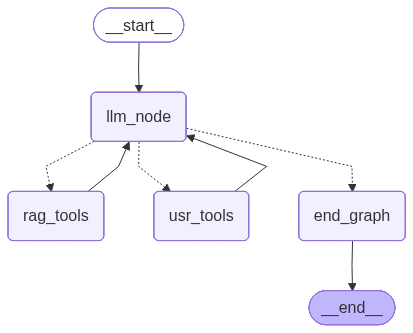

In [59]:
# Setup LangGraph Flow

# Add ToolNode Array
rag_tools = [search_rag]
usr_tools = [do_validate, do_register, notify_user, get_userInfo, get_event_fees, get_event_schedule]

# Build Langgraph Flows
graph_builder = StateGraph(state_schema=State, output_schema=OutputState)

# Add Nodes
graph_builder.add_node("llm_node", chat_llm_node)
graph_builder.add_node("rag_tools", ToolNode(rag_tools))
graph_builder.add_node("usr_tools", ToolNode(usr_tools))
graph_builder.add_node("end_graph", prune_graph_output)


#Add Edges
graph_builder.add_edge(START, "llm_node")
graph_builder.add_conditional_edges("llm_node", tools_condition)
graph_builder.add_edge("usr_tools", "llm_node")
graph_builder.add_edge("rag_tools", "llm_node")
graph_builder.add_edge("end_graph", END)


# Add Checkpoints to Memory
memory= MemorySaver()

# Add Thread-Id to Map the Memory Checkpoint
#graph_config = {"configurable": {"thread_id": 1004}}

graph = graph_builder.compile(checkpointer=memory, name="cust_reg_agent")

# Visualize Graph
display(Image(graph.get_graph().draw_mermaid_png()))


In [60]:
# Registering Users for Events.

# Add Thread-Id to Map the Memory Checkpoint
thread_id = uuid.uuid4()
graph_config = {"configurable": {"thread_id": thread_id}}

# Global Agent Instructions
system_prompt_content = """
Role: You are an AI Assistant for the Running Event. 
Goals: Provide Users with capability to Search, Validate, Register and Notify them for the Running Event.

Message Types:
- User: input directly from the human participant.
- ToolResult: response from an external function/tool execution.
- AI: Assistant's own reasoning or prior responses.
- AI (tool call): Assistant calling registered Tools.
- Context: Represent an Execution Step provided as Input.

Assistant Instructions:
- DO NOT guess Answers.
- DO NOT Add Any Extra Commentary, Suggestions or Leading Qustions to ToolMessage.
- STRICTLY follow the Context Provided by User and ONLY Execute what is said in that Context.
- If a User asks Any Factual Question about the Event, check the FAQ database First. If the FAQ search returns no relevant results, inform the user you could not find an answer.
- When sending notifications, always format the EMail body to address the User. Always include First Name & Last Name in addressing the User in the EMail body. 
- If User make repeat query, and the Memory shows the Answer came from a Tool, Assistant MUST IGNORE Memory and ALWAYS call the respective Tool again.
"""

# - ONLY Perform Activity described in the Current Context.
# DO NOT guess future Execution Steps.
# DO NOT Suggest, Infer, Initiate or Ask the Next Step unless explicitly instructed.
#3. Do Not append future Execution Context to Response of Current Context.
#3. Do not guess future Execution Steps. Align Only with the Current Execution Step that is provided.
# Do not add New Comments respond with leading Questions OR Task Information after successful completion of a Context Execution.

system_prompt = [SystemMessage(content=system_prompt_content)]
resp_message = graph.invoke({"messages": system_prompt}, graph_config)

resp_message    # Print AI Rsponse to Loading System Instruction.


AAA:  content='AI: Hello! How can I assist you with the Running Event today? You can search for event details, validate your information, register, or request notifications. Let me know what you’d like to do!' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 791, 'total_tokens': 832, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_e24a1fec47', 'id': 'chatcmpl-CQ3VNsoAMOAtPZtYuMccjC3wEejL5', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='run--3e5fb676-a13a-4693-8524-056e37c57350-0' usage_metadata={'input_tokens': 791, 'output_tokens': 41, 'total_tokens': 832, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


{'out_messages': [SystemMessage(content="\nRole: You are an AI Assistant for the Running Event. \nGoals: Provide Users with capability to Search, Validate, Register and Notify them for the Running Event.\n\nMessage Types:\n- User: input directly from the human participant.\n- ToolResult: response from an external function/tool execution.\n- AI: Assistant's own reasoning or prior responses.\n- AI (tool call): Assistant calling registered Tools.\n- Context: Represent an Execution Step provided as Input.\n\nAssistant Instructions:\n- DO NOT guess Answers.\n- DO NOT Add Any Extra Commentary, Suggestions or Leading Qustions to ToolMessage.\n- STRICTLY follow the Context Provided by User and ONLY Execute what is said in that Context.\n- If a User asks Any Factual Question about the Event, check the FAQ database First. If the FAQ search returns no relevant results, inform the user you could not find an answer.\n- When sending notifications, always format the EMail body to address the User. Al

In [ ]:
# Start User & AI Interaction - Run through Automated User Registration Flow
# Initiate Chat with AI Calculator

chat_prompt = []
exit_flag = False
skip_plan_step = False
#plan_ctx = "RegisterUser"

def on_key_press(event):
    if event.name == 'esc':
        print("Escape key pressed! Exiting input.")
        global exit_flag
        exit_flag = True
        return True  # Stop the keyboard listener

# Keyboard Listener
keyboard.on_press(on_key_press)

# How to register for the Running Event ?
# I need to Register for the Running Event. Can you help ?
# Here are my details: First Name - Ranjith6, Last Name - Menon6, Age - 48, EMail - rm666@gmail.com, Phone Number - 408-436-6666.

# Prompt User for Input
user_input = input("How can i help?: ")
user_prompt = [HumanMessage(content="User: " + user_input)]
plan_ctx = check_user_intent(user_prompt[0])                    # Derive Plan / Intent from User Qustion.

print("User Execution Plan: ", plan_ctx)                        
resp_message = graph.invoke({"messages": user_prompt}, graph_config) # Pass same above prompt to ChatGPT to get RAG Anwer
print("AI Response: ", resp_message["out_messages"][-1])

# Entering Plan Execution Section.
if (plan_ctx == "RegisterUser"):
    # Get Plan Steps (Keys) & Run through Steps in Sequence
    plan_steps = plan_config.options(plan_ctx)
    plan_length = len(plan_steps)

    idx = 0
    while (idx < plan_length) and (exit_flag == False):
        if (skip_plan_step == False):
            step = plan_steps[idx]
            step_context = plan_config[plan_ctx][step]                                  # Get the Context for the Key.
            print("Reg Context: ", step_context)

            user_input_flag, step_context = check_require_userinput(step_context)       # Check if User need to Provide Input.
            if user_input_flag == True:
                user_input = input(step_context + ": ")                     # Prompt User for Input to Star the Plan
                user_prompt = "Context : " + step_context.strip() + " \n " + "User: " +  user_input
            else:
                user_prompt = "Context : " + step_context.strip()
        else:
            user_input = input("Respond to AI: ")                           # Prompt User Response for AI Question.
            user_prompt = "User: " + user_input.strip()

        chat_prompt = [HumanMessage(content=user_prompt)]
        resp_message = graph.invoke({"messages": chat_prompt}, graph_config)
        ai_resp_intent = check_ai_resp_intent(resp_message["out_messages"][-1])
        print("Intent: ", ai_resp_intent)
        if ai_resp_intent == "QUESTION":            # Check if the AI Response is a Question for User. 
            skip_plan_step = True
        else:
            idx = idx + 1
            skip_plan_step = False
     
resp_message                                        # Print final Raw Output


User Execution Plan:  RegisterUser
AAA:  content='AI: To register you for the Running Event, I’ll need some information from you:\n\n- First Name\n- Last Name\n- Age\n- Email Address\n- Phone Number\n\nPlease provide these details so I can proceed with your registration.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 852, 'total_tokens': 900, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_e24a1fec47', 'id': 'chatcmpl-CQ3W6JYYjLMMNHRzpvrhRoe3N73pU', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='run--5a9d42e9-b3f0-4fb8-b14c-d15d9bfd4998-0' usage_metadata={'input_tokens': 852, 'output_tokens': 48, 'total_tokens': 900, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output

{'out_messages': [SystemMessage(content="\nRole: You are an AI Assistant for the Running Event. \nGoals: Provide Users with capability to Search, Validate, Register and Notify them for the Running Event.\n\nMessage Types:\n- User: input directly from the human participant.\n- ToolResult: response from an external function/tool execution.\n- AI: Assistant's own reasoning or prior responses.\n- AI (tool call): Assistant calling registered Tools.\n- Context: Represent an Execution Step provided as Input.\n\nAssistant Instructions:\n- DO NOT guess Answers.\n- DO NOT Add Any Extra Commentary, Suggestions or Leading Qustions to ToolMessage.\n- STRICTLY follow the Context Provided by User and ONLY Execute what is said in that Context.\n- If a User asks Any Factual Question about the Event, check the FAQ database First. If the FAQ search returns no relevant results, inform the user you could not find an answer.\n- When sending notifications, always format the EMail body to address the User. Al

In [ ]:
# Start User & AI Interaction - Lookup FAQ for User Reg Instructions

# user_input = input("User:") "How to register for the Running Event ?"
#user_prompt = [HumanMessage(content="User: " + "How to register for the Running Event ?")]
#resp_message = graph.invoke({"messages": user_prompt}, graph_config)

#resp_message   # Print teh raw output


In [ ]:
# Provide User Registration Plan to Agent
#reg_plan_prompt = [SystemMessage(content="Plan: " + user_reg_plan)]
#resp_message = graph.invoke({"messages": reg_plan_prompt}, graph_config)

#resp_message   # Response with Plan

In [ ]:
# Start User & AI Interaction - Run through Automated User Registration Flow

# Provide User Information as Input to AI
#user_prompt = [HumanMessage(content="Context: Validate User.\n User: Here are my details: First Name - Ranjith6, Last Name - Menon6, Age - 48, EMail - rm666@gmail.com, Phone Number - 408-436-6666.")]
#resp_message = graph.invoke({"messages": user_prompt}, graph_config)

# Provide User Information as Input to AI
#user_prompt = [HumanMessage(content="Context: Register User.")]
#resp_message = graph.invoke({"messages": user_prompt}, graph_config)

# Provide User Information as Input to AI
#user_prompt = [HumanMessage(content="Context: Check for Event Fees.")]
#resp_message = graph.invoke({"messages": user_prompt}, graph_config)

# Provide User Information as Input to AI
#user_prompt = [HumanMessage(content="Context: Respond with overall Status of Registeration.")]
#resp_message = graph.invoke({"messages": user_prompt}, graph_config)

#resp_message   # Print teh raw output

In [ ]:
# Scratch Pad

#faq_content = []
#try:
#    with open("C:\\RanjithC\\AIProjects\\PromptEngg\\langgraph\\data\\runevent_faq.txt", "r") as file:
#        faq_content = file.readlines() # Reads the entire file content into a string
#        for i, item in enumerate(faq_content):
#            faq_content[i] = item.strip()
#except Exception as e:
#    print("An error occurred:", e)
#print(faq_content) 

# 1. Override langgraph default 'tools_condition'
# def tools_condition(state: State) -> Literal["tools", END]:   
#    for msg in state["messages"]:
#        if isinstance(msg, AIMessage):
#            msg_content = msg.additional_kwargs.get("tool_calls")
#    print("AAA: ", (msg_content[0]).get("function").get("name"))
#        return()
#
# Example AIMessage that above code will parse and get 'addition' as the funcation name
# AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_6FKMED5sgAkasLAB0LclWfDu', 'function': {'arguments': '{"num1":10,"num2":5}', 'name': 'addition'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 154, 'total_tokens': 174, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_ff25b2783a', 'id': 'chatcmpl-C2RCQuPtUjyBhFd4F5i4jCqiSDjIR', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--c79dea77-ae2b-405c-b15c-10d728e32c41-0', tool_calls=[{'name': 'addition', 'args': {'num1': 10, 'num2': 5}, 'id': 'call_6FKMED5sgAkasLAB0LclWfDu', 'type': 'tool_call'}], usage_metadata={'input_tokens': 154, 'output_tokens': 20, 'total_tokens': 174, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})
#
# resp_message = list(filter(filter_message, resp_message["messages"]))   # State Object Filtering Logic
# list(filter(<filter_function>, datalist)) - Automatically each Values will be looped thru in the list
#   Same function will be called sequentially for individual values in the list.
#   The function should return True or False Value sent to the function.
#   For all retuen is False, that index value will be removed from list.  

#System Prompt
#Role: You are an Assistant for a Running Event. 
#Goals: Use the Tools provided to Search, Register and Notify Users for the Running Event.
#Instructions to Assistant: 
#1. Do not guess answers.
#2. If a user asks any factual question about the event, check the FAQ database first. If the FAQ search returns no relevant results, inform the user you could not find an answer.
#3. If the Registration is a Failure, First Get the Schedule and include that in the User Notification on the Registration Status.
#4. If the Registration is Successful, First Get the Event Schedule, Second Get the Event Fees and Include Both the results in the User Notification on the Registration Status. 
#5. If User request to Check Fees, after checking, ask the User if Fee information need to be EMailed.
#6. When sending notifications, always format the EMail body to address the User. Always include First Name & Last Name in addressing the User in the EMail body. """
#5. If User request to Check Fees, after checking, always send an EMail Notification to user with Fee Detail.

# Get Fees - AI will prompt back on EMail and USer can decide if EMail is need to be sent or not.
#user_prompt = [HumanMessage(content="What is the User Fee for registering in the Event ?")]
#resp_message = graph.invoke({"messages": user_prompt}, graph_config)
#resp_message = graph.invoke({"messages": resp_message["out_messages"] + user_prompt}, graph_config)
#user_input = input("User: ")
#user_prompt = [HumanMessage(content=user_input)]
#resp_message = graph.invoke({"messages": user_prompt}, graph_config)
#resp_message = graph.invoke({"messages": resp_message["out_messages"] + user_prompt}, graph_config)

#user_reg_instructions = """
#Assistant need to Execute the below Steps in a Sequence to Register User for the Run Event based on the User Information provided.
#On Failure of any Steps, Assistant SHOULD respond to the User IMMEDIATLY with the Failure Information for the Step. Wait for further Input or Instructions from User. 
#Step-1:Validate User Information.
#Step-2:Register User Information.
#Step-3:Check for Fees.
#Step-4:Respond with overall Status of Registration.
#"""

#5. Plan: Execution Plans provided by human participant to the Assistant.
#5. If Assistant is provided with an Execution Plan, DO NOT RUN the Plan Steps automatically. User WILL Provide when each Step in the Plan needs to be executed.

#Assistant need to execute the below Steps in a Sequence to Register the User, based on Information provided.
#On Failure of any Step, Assistant SHOULD respond to the User IMMEDIATLY with the Failure Information for that Step. Then Wait for further Input or Instructions from User.

# Running the Plan
#    reg_context = plan_config[plan_ctx][step]
#    print("Reg Context: ", reg_context)
#    if step.lower() == "step-1":
#        user_prompt = "Context: " + reg_context.strip() + " \n " + "User: " +  user_input
#    else:
#        user_prompt = "Context: " + reg_context.strip()
#    chat_prompt = [HumanMessage(content=user_prompt)]
#    resp_message = graph.invoke({"messages": chat_prompt}, graph_config)
#    ai_resp_intent = check_ai_resp_intent(resp_message["out_messages"][-1])
#    print("Intent: ", ai_resp_intent)


#while (idx < plan_length) and (exit_flag == False):
#    if skip_plan_step == False:
#        step = plan_steps[idx]
#        reg_context = plan_config[plan_ctx][step]            # Get the Context for the Key.
#        print("Reg Context: ", reg_context)
#        if step.lower() == "step-1":
#            user_prompt = "Context: " + reg_context.strip()  # + " \n " + "User: " +  user_input
#        else:
#            user_prompt = "Context: " + reg_context.strip()
#    else:
#        user_input = input("User Response to AI: ")         # Prompt User Response for AI Question.
#        user_prompt = "User: " + user_input.strip()

#    chat_prompt = [HumanMessage(content=user_prompt)]
#    resp_message = graph.invoke({"messages": chat_prompt}, graph_config)
#    ai_resp_intent = check_ai_resp_intent(resp_message["out_messages"][-1])
#    print("Intent: ", ai_resp_intent)
#    if ai_resp_intent == "QUESTION":
#        skip_plan_step = True
#    else:
#        idx = idx + 1
#        skip_plan_step = False

# Prompt User for details
#user_input = input("User Input: ")                  # Here are my details: First Name - Ranjith6, Last Name - Menon6, Age - 48, EMail - rm666@gmail.com, Phone Number - 408-436-6666.
#user_prompt = [HumanMessage(content="User: " + user_input)]
#resp_message = graph.invoke({"messages": user_prompt}, graph_config)
#print("AI Response: ", resp_message["out_messages"][-1])

#Instructions to Assistant: 
#1. Do not guess answers.
#2. Do not guess future Execution Steps, when a Context is provided for Execution to the Assistant.
#3. Do not respond with leading Questions OR Tasks after successful completion of a Context Execution.
#4. If a user asks any Factual Question about the Event, check the FAQ database First. If the FAQ search returns no relevant results, inform the user you could not find an answer.
#5. When sending notifications, always format the EMail body to address the User. Always include First Name & Last Name in addressing the User in the EMail body. 
#6. If User make repeat query, and the Memory shows the Answer came from a Tool, Assistant MUST IGNORE Memory and ALWAYS call the respective Tool again.

# Assistant Instruction: DO NOT PROCEED TO NEXT STEP. DO NOT ASK USER QUESTIONS."  #User Information Update Successful